In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
from pathlib import Path
import mne

In [4]:
data_folder = Path('../Data/')
raw_data_folder = Path('../Data/raw_data/')

In [5]:
data_labels = pd.read_csv(data_folder / "preprocessed_data.csv")

In [6]:
data_labels.head()

,subject,trial,kind,file_name,stress_level
0,1,1,Relax,Relax_sub_1_trial1.mat,0
1,1,1,Mirror,Mirror_image_sub_1_trial1.mat,3
2,1,1,Arithmetic,Arithmetic_sub_1_trial1.mat,6
3,1,1,Stroop,Stroop_sub_1_trial1.mat,3
4,1,2,Mirror,Mirror_image_sub_1_trial2.mat,5


In [7]:
data_labels.shape

(480, 5)

In [8]:
data_labels["kind"].value_counts()

kind
Relax         120
Mirror        120
Arithmetic    120
Stroop        120
Name: count, dtype: int64

In [9]:
stress_df = data_labels[data_labels["kind"] != "Relax"].copy()

In [10]:
stress_df["kind"].value_counts()

kind
Mirror        120
Arithmetic    120
Stroop        120
Name: count, dtype: int64

## process each file

In [11]:
SFREQ = 128
N_CHANNELS = 32

LOW_FREQ = 0.5
HIGH_FREQ = 45

In [12]:
def process_file(filepath: str):
    mat = loadmat(filepath)
    data = mat['Data'] # data.shape => (32, 3200) -> 32 channels, 3200 samples

    ch_names = [
        f"EEG{i:03d}"
        for i in range(1, N_CHANNELS + 1)
    ]


    info = mne.create_info(
        ch_names=ch_names,
        sfreq=SFREQ,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(
        data,
        info,
        verbose=False
    )

    raw_filtered = raw.copy()

    raw_filtered.filter(
        l_freq=LOW_FREQ,
        h_freq=HIGH_FREQ,
        verbose=False
    )


    ica = mne.preprocessing.ICA(
        n_components=15,
        random_state=42,
        max_iter=1000,
        method="picard",
        fit_params={"tol": 0.01}
    )

    ica.fit(
        raw_filtered,
        verbose=False,
    )


    raw_clean = raw_filtered.copy()


    ica.apply(
        raw_clean,
        verbose=False
    )

    epochs = mne.make_fixed_length_epochs(
        raw_clean,
        duration=2.0,
        overlap=1.0,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()
    file_path = str(filepath).split("/")[-1]


    n_epochs = X.shape[0]

    metadata = data_labels[data_labels['file_name'] == file_path][['subject', 'trial', 'kind', 'stress_level']]
    metadata = pd.concat([metadata] * n_epochs, ignore_index=True)

    return X, metadata

In [13]:
filepath = raw_data_folder / "Mirror_image_sub_1_trial1.mat"
X, metadata = process_file(filepath)
metadata

,subject,trial,kind,stress_level
0,1,1,Mirror,3
1,1,1,Mirror,3
2,1,1,Mirror,3
3,1,1,Mirror,3
4,1,1,Mirror,3
5,1,1,Mirror,3
6,1,1,Mirror,3
7,1,1,Mirror,3
8,1,1,Mirror,3
9,1,1,Mirror,3


In [14]:
print(X.shape)

(24, 32, 256)


## Build The Entire Dataset

In [15]:
all_X = []
all_metadata = []

for _, row in data_labels.iterrows():
    file_path = raw_data_folder / row['file_name']
    X, metadata = process_file(file_path)

    all_X.append(X)
    all_metadata.append(metadata)


# Combine all EEG epochs
X_full = np.concatenate(
    all_X,
    axis=0
)

# Combine metadata
metadata_full = pd.concat(
    all_metadata,
    ignore_index=True
)


In [16]:
print("X_full:", X_full.shape)
print("metadata_full:", metadata_full.shape)

print(metadata_full.head())

X_full: (11520, 32, 256)
metadata_full: (11520, 4)
   subject  trial   kind  stress_level
0        1      1  Relax             0
1        1      1  Relax             0
2        1      1  Relax             0
3        1      1  Relax             0
4        1      1  Relax             0


In [17]:
metadata_full["stress_level"].value_counts().sort_index()

stress_level
0     2880
1      456
2      600
3     1392
4     1296
5     1848
6     1368
7      768
8      576
9      240
10      96
Name: count, dtype: int64

In [18]:
print(
    metadata_full.groupby("kind")["stress_level"].agg(
        ["count", "mean", "min", "max"]
    )
)

            count      mean  min  max
kind                                 
Arithmetic   2880  5.441667    1   10
Mirror       2880  4.941667    1    9
Relax        2880  0.000000    0    0
Stroop       2880  4.050000    1    9


## Save

In [19]:
np.save(
    "../Data/processed/X.npy",
    X_full
)

metadata_full.to_csv(
    "../Data/processed/metadata.csv",
    index=False
)

# Split the data

In [20]:
# 32 subjects -> training
# 8 subjects  -> testing

subjects = metadata_full["subject"].unique()
print("Number of subjects:", len(subjects))
print("Subjects:", subjects)

Number of subjects: 40
Subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


In [21]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_full,
        groups=metadata_full["subject"]
    )
)

In [22]:
X_train = X_full[train_idx]
X_test = X_full[test_idx]

metadata_train = metadata_full.iloc[train_idx].reset_index(drop=True)
metadata_test = metadata_full.iloc[test_idx].reset_index(drop=True)

In [23]:
train_subjects = set(metadata_train["subject"])
test_subjects = set(metadata_test["subject"])

print("Train subjects:", sorted(train_subjects))
print("Test subjects:", sorted(test_subjects))

print("Number of train subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

print("Overlap:", train_subjects.intersection(test_subjects))

Train subjects: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 14, 15, 18, 19, 21, 22, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40]
Test subjects: [5, 13, 16, 17, 20, 27, 28, 38]
Number of train subjects: 32
Number of test subjects: 8
Overlap: set()


In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("metadata_train:", metadata_train.shape)
print("metadata_test:", metadata_test.shape)

X_train: (9216, 32, 256)
X_test: (2304, 32, 256)
metadata_train: (9216, 4)
metadata_test: (2304, 4)


In [25]:
y_train = metadata_train["stress_level"].to_numpy()
y_test = metadata_test["stress_level"].to_numpy()

In [26]:
print(y_train.shape)
print(y_test.shape)

(9216,)
(2304,)


# Make it Binary

In [27]:
metadata_train["stress_binary"] = (
    metadata_train["stress_level"] >= 4
).astype(int)

metadata_test["stress_binary"] = (
    metadata_test["stress_level"] >= 4
).astype(int)

In [28]:
y_train = metadata_train["stress_binary"].to_numpy()
y_test = metadata_test["stress_binary"].to_numpy()

In [29]:
print("Train:")
print(metadata_train["stress_binary"].value_counts())

print("\nTest:")
print(metadata_test["stress_binary"].value_counts())

Train:
stress_binary
1    4896
0    4320
Name: count, dtype: int64

Test:
stress_binary
1    1296
0    1008
Name: count, dtype: int64


In [30]:
print(
    metadata_train
    .groupby("stress_binary")["stress_level"]
    .agg(["count", "min", "max", "mean"])
)

               count  min  max      mean
stress_binary                           
0               4320    0    3  1.100000
1               4896    4   10  5.661765


# Feature Extraction

In [31]:
from mne.time_frequency import psd_array_welch

In [32]:
def extract_band_power(X, sfreq=128):
    
    """
    X shape:
        (n_epochs, n_channels, n_samples)

    Returns:
        features shape:
        (n_epochs, n_channels * n_bands)
    """

    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    psds, freqs = psd_array_welch(
        X,
        sfreq=sfreq,
        fmin=1,
        fmax=45,
        n_fft=256,
        verbose=False
    )

    # psds:
    # (epochs, channels, frequencies)

    features = []

    for band_name, (low, high) in bands.items():

        freq_mask = (
            (freqs >= low) &
            (freqs < high)
        )

        band_power = psds[:, :, freq_mask].mean(axis=2)

        features.append(band_power)

    # (epochs, channels, bands)
    features = np.stack(features, axis=2)

    # Flatten
    n_epochs = features.shape[0]

    features = features.reshape(
        n_epochs,
        -1
    )

    return features

In [33]:
X_train_features = extract_band_power(X_train)
X_test_features = extract_band_power(X_test)

In [34]:
print(X_train_features.shape)
print(X_test_features.shape)

(9216, 160)
(2304, 160)


# Standardize the features

In [35]:
print(X_train_features.min())
print(X_train_features.max())

0.03759680106086731
35046.755428613214


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)

X_test_scaled = scaler.transform(X_test_features)

In [37]:
print(
    X_train_scaled.mean(),
    X_train_scaled.std()
)

1.3322676295501878e-16 1.0


# ML model

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [39]:
model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# Predictions

In [40]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.5707465277777778
Precision: 0.6109906001446131
Recall   : 0.6520061728395061
F1       : 0.6308324001493094
ROC-AUC  : 0.5949433850186165


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[470, 538],
       [451, 845]])

### Check class imbalance

In [44]:
print("Train:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest:")
print(pd.Series(y_test).value_counts(normalize=True))

Train:
1    0.53125
0    0.46875
Name: proportion, dtype: float64

Test:
1    0.5625
0    0.4375
Name: proportion, dtype: float64


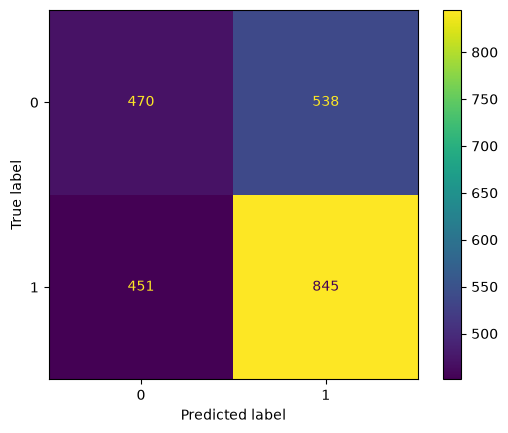

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.47      0.49      1008
           1       0.61      0.65      0.63      1296

    accuracy                           0.57      2304
   macro avg       0.56      0.56      0.56      2304
weighted avg       0.57      0.57      0.57      2304



# Random Forest 

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(
    X_train_features,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [48]:
y_pred_rf = rf.predict(X_test_features)

y_prob_rf = rf.predict_proba(X_test_features)[:, 1]

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1       :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.5386284722222222
Precision: 0.6013925152306353
Recall   : 0.533179012345679
F1       : 0.5652351738241309
ROC-AUC  : 0.5563459147805212

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.55      0.51      1008
           1       0.60      0.53      0.57      1296

    accuracy                           0.54      2304
   macro avg       0.54      0.54      0.54      2304
weighted avg       0.55      0.54      0.54      2304



# SVM

In [50]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

/Users/parsa/Desktop/projects/github/pxsa/EEG-stress-xai/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [51]:
print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1       :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm))

SVM
Accuracy : 0.5442708333333334
Precision: 0.5862552594670407
Recall   : 0.6450617283950617
F1       : 0.6142542248346804
ROC-AUC  : 0.5311738346315893


# Gradient Boosting

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_features, y_train)

y_pred_gb = gb.predict(X_test_features)
y_prob_gb = gb.predict_proba(X_test_features)[:, 1]

In [54]:
print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1       :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting
Accuracy : 0.5594618055555556
Precision: 0.6044609665427509
Recall   : 0.6273148148148148
F1       : 0.6156758803483529
ROC-AUC  : 0.5839755719674702


# XGBoost

In [55]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_features, y_train)

y_pred_xgb = xgb.predict(X_test_features)
y_prob_xgb = xgb.predict_proba(X_test_features)[:, 1]

In [56]:
print("XGBoost")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1       :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

XGBoost
Accuracy : 0.5577256944444444
Precision: 0.6101829753381066
Recall   : 0.591820987654321
F1       : 0.6008617312965139
ROC-AUC  : 0.5844034758965314


# KNN

In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [58]:
print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1       :", f1_score(y_test, y_pred_knn))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_knn))

KNN
Accuracy : 0.5494791666666666
Precision: 0.5894590846047156
Recall   : 0.6558641975308642
F1       : 0.620891161431702
ROC-AUC  : 0.5495733208406819


In [60]:
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },

    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1": f1_score(y_test, y_pred_svm),
        "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
    },

    "Gradient Boosting": {
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall": recall_score(y_test, y_pred_gb),
        "F1": f1_score(y_test, y_pred_gb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_gb)
    },

    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    },

    "KNN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1": f1_score(y_test, y_pred_knn),
        "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
    }
}

In [ ]:
results_df = pd.DataFrame(results).T

print(results_df.sort_values("ROC-AUC", ascending=False))

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.570747   0.610991  0.652006  0.630832  0.594943
XGBoost              0.557726   0.610183  0.591821  0.600862  0.584403
Gradient Boosting    0.559462   0.604461  0.627315  0.615676  0.583986
KNN                  0.549479   0.589459  0.655864  0.620891  0.549573
Random Forest        0.539497   0.588679  0.601852  0.595193  0.547766
SVM                  0.544271   0.586255  0.645062  0.614254  0.531174


# Shap